**The goal of this exercise is to evaluate the median forecast of unemployment from the Survey of Professional Forecasters (SPF). The file unemp_forecast.xls contains the median one-quarter ahead forecast of unemployment. The file unemp_realizations.xls contains the realizations of unemployment for the corresponding quarter. Do the following:**

In [2]:
# Import 'Data for tutorial 6.xlsx' as dataframe
import pandas as pd
df = pd.read_excel('Data for tutorial 6.xlsx')
df.drop(columns=['time'], inplace=True)
df = df.dropna()

print(df.columns, f'Length: {len(df)} rows')
df.head()

Index(['unemp_effect', 'unem_forecast'], dtype='str') Length: 144 rows


,unemp_effect,unem_forecast
0,3.4,3.8
1,3.4,3.6
2,3.6,3.8
3,3.6,4.1
4,4.2,4.3


**(a) Plot the forecast and the realizations and comment (e.g., do we see consistent under- or over-predicting? Is there any pattern over time?)**

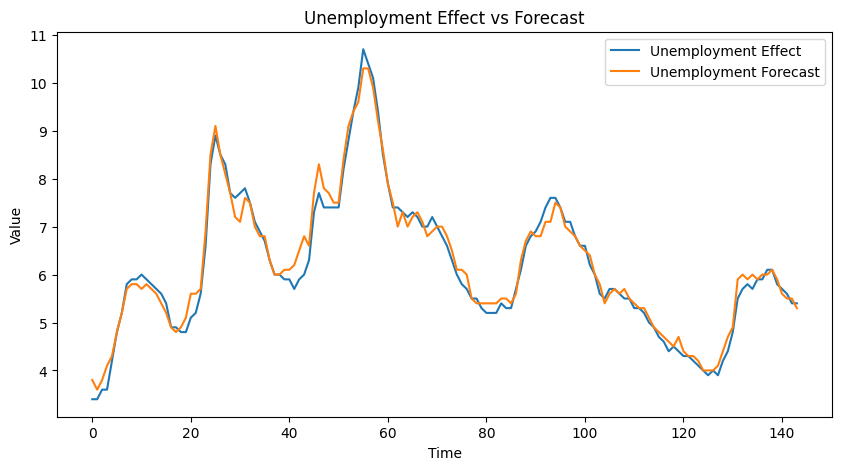

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df['unemp_effect'], label='Unemployment Effect')
plt.plot(df['unem_forecast'], label='Unemployment Forecast')
plt.title('Unemployment Effect vs Forecast')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

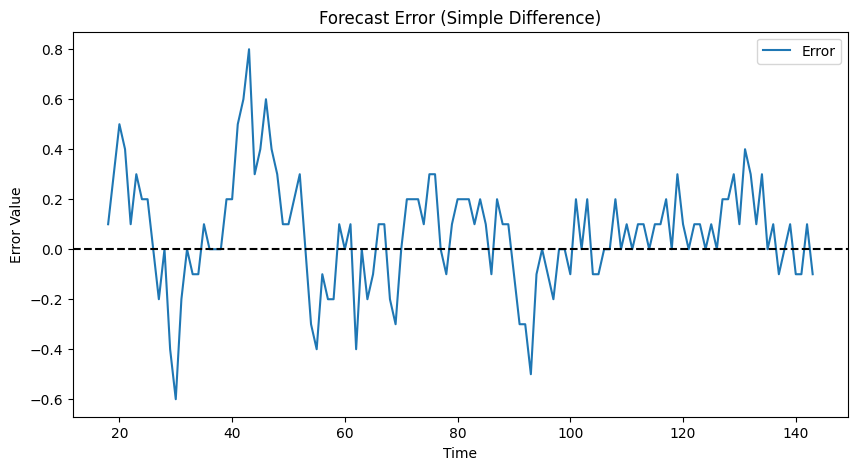

In [6]:
df['diff'] = df['unem_forecast'] - df['unemp_effect']

plt.figure(figsize=(10, 5))
plt.plot(df['diff'], label='Error')
plt.title('Forecast Error (Simple Difference)')
plt.xlabel('Time')
plt.ylabel('Error Value')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()

In [9]:
# Run t-tests for weak stationarity
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Create a weak stationarity dataframe to store results
ws_testdf = pd.DataFrame({
	'H0': [],
	'T-statistic': [],
	'P-value': []
})

# Overall unconditional mean
print(f'Overall Unconditional Mean: {np.round(df["diff"].mean(), 3)}')
t_stat, p_value = stats.ttest_1samp(df['diff'], 0)
ws_testdf.loc[len(ws_testdf)] = {
	'H0': 'E(diff_t) = 0',
	'T-statistic': t_stat,
	'P-value': p_value
}

# Split data into two halves and test whether means are equal
midpoint = len(df) // 2
first_half = df['diff'][:midpoint]
second_half = df['diff'][midpoint:]
t_stat_half, p_value_half = stats.ttest_ind(first_half, second_half)
print(f'First half variance: {np.round(np.var(first_half, ddof=1), 3)}, Second half variance: {np.round(np.var(second_half, ddof=1), 3)}')
ws_testdf.loc[len(ws_testdf)] = {
	'H0': 'E(diff_first_half) = E(diff_second_half)',
	'T-statistic': t_stat_half,
	'P-value': p_value_half
}

# Compare variance
var_first_half = np.var(first_half, ddof=1)
var_second_half = np.var(second_half, ddof=1)
f_stat = (var_first_half / var_second_half) if var_second_half > 0 else np.inf
p_value_var = 2 * min(stats.f.cdf(f_stat, len(first_half) - 1, len(second_half) - 1), 1 - stats.f.cdf(f_stat, len(first_half) - 1, len(second_half) - 1))
ws_testdf.loc[len(ws_testdf)] = {
	'H0': 'Var(diff_first_half) = Var(diff_second_half)',
	'T-statistic': f_stat,
	'P-value': p_value_var
}

# Run covariance stationarity test by checking autocorrelation at lags 4, 6, 8
# And checking if it differs depending on the time period but not length of lag
for lag in [4, 6, 8]:
	autocorr_first_half = first_half.autocorr(lag=lag)
	autocorr_second_half = second_half.autocorr(lag=lag)
	# Run a t-test to check if autocorrelations differ significantly
	# Note: This is a simplified approach and may not be the most rigorous method for testing autocorrelation differences
	autocorr_diff = autocorr_first_half - autocorr_second_half
	# Assuming a standard error for the difference in autocorrelations (this is a simplification
	autocorr_se = np.sqrt((1 / len(first_half)) + (1 / len(second_half)))
	t_stat_autocorr = autocorr_diff / autocorr_se if autocorr_se > 0 else 0
	p_value_autocorr = 2 * (1 - stats.norm.cdf(abs(t_stat_autocorr)))
	ws_testdf.loc[len(ws_testdf)] = {
		'H0': f'Autocorr(diff_first_half, lag={lag}) = Autocorr(diff_second_half, lag={lag})',
		'T-statistic': t_stat_autocorr,
		'P-value': p_value_autocorr
	}


# ADF test to check for unit roots
adf_result = adfuller(df['diff'])
ws_testdf.loc[len(ws_testdf)] = {
	'H0': 'Unit root exists (non-stationary)',
	'T-statistic': adf_result[0],
	'P-value': adf_result[1]
}

ws_testdf['Outcome'] = np.where(ws_testdf['P-value'] < 0.05, 'R (H1)', 'Fail (H0)')
print('\nWeak Stationarity Test Results:')
print(np.round(ws_testdf, 4).to_string(index=False))


Overall Unconditional Mean: 0.064
First half variance: 0.07, Second half variance: 0.025

Weak Stationarity Test Results:
                                                                  H0  T-statistic  P-value   Outcome
                                                       E(diff_t) = 0       3.3188   0.0012    R (H1)
                            E(diff_first_half) = E(diff_second_half)       0.8595   0.3917 Fail (H0)
                        Var(diff_first_half) = Var(diff_second_half)       2.8216   0.0001    R (H1)
Autocorr(diff_first_half, lag=4) = Autocorr(diff_second_half, lag=4)       1.0622   0.2882 Fail (H0)
Autocorr(diff_first_half, lag=6) = Autocorr(diff_second_half, lag=6)      -0.0337   0.9732 Fail (H0)
Autocorr(diff_first_half, lag=8) = Autocorr(diff_second_half, lag=8)      -0.1139   0.9093 Fail (H0)
                                   Unit root exists (non-stationary)      -4.2273   0.0006    R (H1)


### Forecasting error series summary
- The average difference in this sample is above 0 at 0.064. This is significantly different from zero for this sample.
- This series fails weak stationarity test as the variance is not constant over the series (significantly more variance in the first half).
- Running an ADF test suggests we wouldn't model this series through a unit root process however (process has ergodicity).

**(b) Conduct a forecast unbiasedness test using a squared error loss function. Are the forecasts unbiased?**  
**(c) Test whether the one-quarter-ahead forecast errors are uncorrelated.**

In [ ]:
# Conduct a forecast unbiasedness test using a squared error loss function. Are the forecasts unbiased?

# Mean squared error
df['mse'] = df['diff'] ** 2

mse_testdf = pd.DataFrame({
	'H0': [],
	'T-statistic': [],
	'P-value': []
})

# Biasedness test: Check if the mean of the forecast errors is significantly different from zero
t_stat_mse, p_value_mse = stats.ttest_1samp(df['mse'], 0)
mse_testdf.loc[len(mse_testdf)] = {
	'H0': 'E(mse) = 0',
	'T-statistic': t_stat_mse,
	'P-value': p_value_mse
}

# Check if MSEs have autocorrelation
for lag in [4, 6, 8]:
	autocorr_mse = df['mse'].autocorr(lag=lag)
	# Run a t-test to check if autocorrelation differs significantly from zero
	autocorr_se_mse = np.sqrt(1 / len(df))
	t_stat_autocorr_mse = autocorr_mse / autocorr_se_mse if autocorr_se_mse > 0 else 0
	p_value_autocorr_mse = 2 * (1 - stats.norm.cdf(abs(t_stat_autocorr_mse)))
	mse_testdf.loc[len(mse_testdf)] = {
		'H0': f'Autocorr(mse, lag={lag}) = 0',
		'T-statistic': t_stat_autocorr_mse,
		'P-value': p_value_autocorr_mse
	}
mse_testdf['Outcome'] = np.where(mse_testdf['P-value'] < 0.05, 'R (H1)', 'Fail (H0)')
print('\nForecast Unbiasedness Test Results:')
print(np.round(mse_testdf, 4).to_string(index=False))



Forecast Unbiasedness Test Results:
                                 H0  T-statistic  P-value   Outcome
E(mse) = 0 (Forecasts are unbiased)       6.3899   0.0000    R (H1)
           Autocorr(mse, lag=4) = 0       1.6684   0.0952 Fail (H0)
           Autocorr(mse, lag=6) = 0      -0.5389   0.5900 Fail (H0)
           Autocorr(mse, lag=8) = 0      -0.9699   0.3321 Fail (H0)


- Forecasts are definitelyy **biased** (significant at 1% confidence level).
- Errors are not autocorrelated (suggests a mean / constant problem).

**(d) Plot the autocorrelogram and partial autocorrelogram of the forecast errors. Do they suggest that the forecast errors are white noise?**

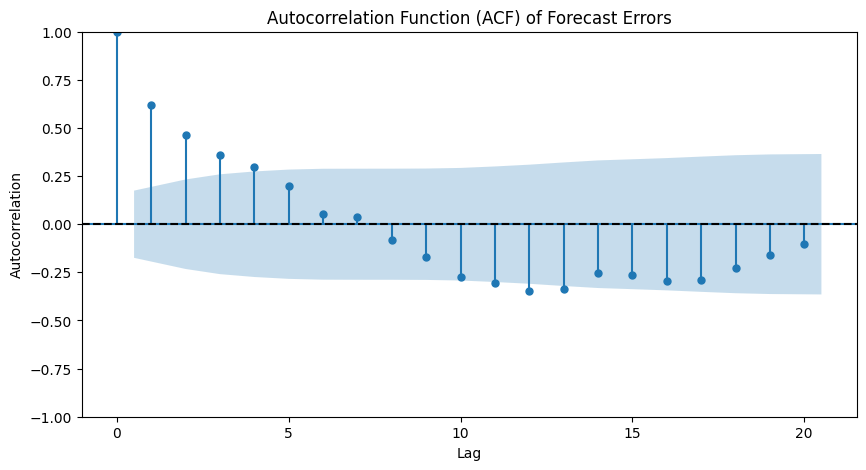

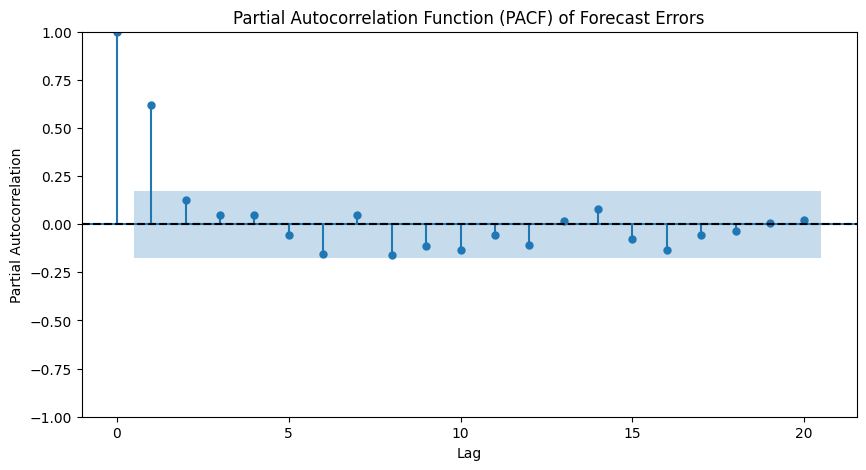

In [18]:
# Plot the autocorrelation function (ACF) of the forecast errors to visually inspect for any patterns or autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10, 5))
plot_acf(df['diff'], lags=20, ax=plt.gca(), alpha=0.05) 
plt.title('Autocorrelation Function (ACF) of Forecast Errors')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.axhline(0, color='black', linestyle='--')
plt.show()

# Plot the partial autocorrelation function (PACF) of the forecast errors to identify the order of any autoregressive process
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(10, 5))
plot_pacf(df['diff'], lags=20, ax=plt.gca(), alpha=0.05)
plt.title('Partial Autocorrelation Function (PACF) of Forecast Errors')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.axhline(0, color='black', linestyle='--')
plt.show()

- Forecasting errors have autocorrelation to a significant level for lags 1-4
- This suggests a misspecified model as forecast errors should be white noise.

**(e) Construct sequences of one-step-ahead forecasts of unemployment using an $AR(p)$ model estimated over the first $m = 50$ observations, selecting $p$ by BIC over the first estimation window. Compare the out-of-sample performance of the $AR(p)$ forecasts to that of the SPF forecasts over the remaining observations by comparing the Mean Square Forecast Error for the two forecasts over the out-of-sample portion.**

In [ ]:
# Run a BIC on df['unemp_effect'] and choose the best model based on the BIC value. Does it differ from the AR(1) model?
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

# 1. Define max lag and create all required lags first
max_lag = 10
for lag in range(1, max_lag + 1):
    df[f'lag_{lag}'] = df['unemp_effect'].shift(lag)

fit_df = df.dropna()
bic_info = []

for lag in range(1, max_lag + 1):
	X = fit_df[[f'lag_{lag}' for lag in range(1, lag + 1)]]
	Y = fit_df['unemp_effect']
      
	ols_model = LinearRegression()
	ols_model.fit(X, Y)
	n = len(fit_df)
	k = len(X.columns)
	bic = n * np.log(np.sum((Y - ols_model.predict(X)) ** 2) / n) + k * np.log(n)
	bic_info.append((lag, bic))

bic_df = pd.DataFrame(bic_info, columns=['Lag', 'BIC'])
bic_star = bic_df.loc[bic_df['BIC'].idxmin()]
print(f'Best model based on BIC: AR({bic_star["Lag"]}) with BIC = {bic_star["BIC"]:.2f}')

# ---

# 1. Automatically select the best lag based on BIC AR package
selection = ar_select_order(df['unemp_effect'].dropna(), 
	maxlag=10, ic='bic', glob=False)

best_lag = selection.ar_lags[-1] if selection.ar_lags else 0

# 2. Fit the optimal model
model = selection.model.fit()
print(f'Best model based on AutoReg BIC: AR({best_lag}) with BIC: {model.bic:.2f}')


Best model based on BIC: AR(2.0) with BIC = -330.86
Best model based on AutoReg BIC: AR(2) with BIC: 40.74


Our BIC lag selection of **2** lines up with results obtained plotting the PACF at 95% confidence level.

                            OLS Regression Results                            
Dep. Variable:           unemp_effect   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     302.3
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.20e-23
Time:                        13:14:08   Log-Likelihood:                -9.1595
No. Observations:                  40   AIC:                             24.32
Df Residuals:                      37   BIC:                             29.39
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6391      0.306      2.085      0.0

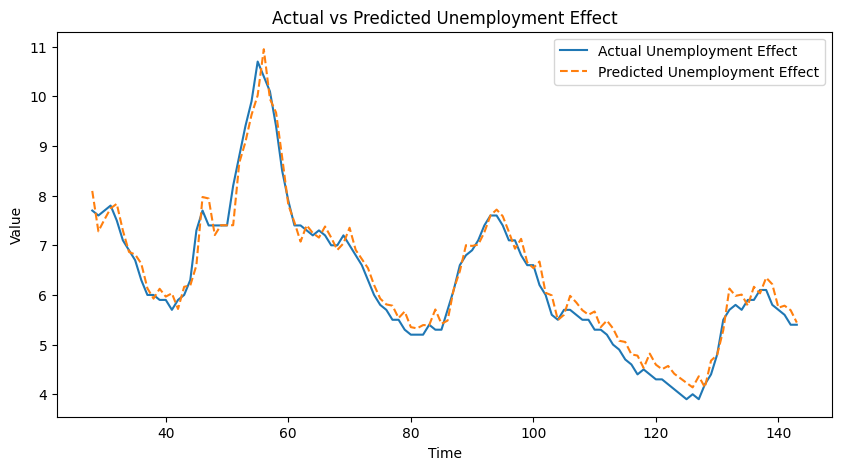

In [53]:
# From the ACF plot, we see that the error autocorrelations are significant up to lag 4.
# Based on PACF plot, we choose an AR(1) model since the partial autocorrelation is significant at lag 1 but not beyond that.

# Estimate an AR(p) model on the first 50 observations.

import statsmodels.api as sm

lags = int(bic_star['Lag'])

test_df = df.head(50).copy()
for lag in range(1, lags + 1):
	test_df[f'lag_{lag}'] = test_df['unemp_effect'].shift(lag)
test_df = test_df.dropna()

X = test_df[[f'lag_{lag}' for lag in range(1, lags + 1)]]
X = sm.add_constant(X)  # Add constant term for intercept
Y = test_df['unemp_effect']
ols_results = sm.OLS(Y, X).fit()

# 3. Print the summary to check significance
print(ols_results.summary())

# Extracting the p-value for the lag_1 coefficient
p_value = ols_results.pvalues['lag_1']
is_significant = p_value < 0.05
print(f"Lag 1 Coefficient is significant: {is_significant} (p={p_value:.4f})")

# Predict the original series using the fitted AR(2) model and compare it to the actual values. Plot the predicted vs actual values.
X_fit = fit_df[[f'lag_{lag}' for lag in range(1, lags + 1)]]
X_fit = sm.add_constant(X_fit)  # Add constant term for intercept
fit_df['predicted'] = ols_results.predict(X_fit)
plt.figure(figsize=(10, 5))
plt.plot(fit_df['unemp_effect'], label='Actual Unemployment Effect')
plt.plot(fit_df['predicted'], label='Predicted Unemployment Effect', linestyle='--')
plt.title('Actual vs Predicted Unemployment Effect')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


New Forecast Unbiasedness Test Results:
                          H0  T-statistic  P-value   Outcome
              E(new_mse) = 0       7.8609   0.0000    R (H1)
Autocorr(new_mse, lag=4) = 0      -0.6481   0.5169 Fail (H0)
Autocorr(new_mse, lag=6) = 0      -1.0563   0.2908 Fail (H0)
Autocorr(new_mse, lag=8) = 0      -1.0301   0.3030 Fail (H0)
New Forecast Unconditional Mean Error: -0.161


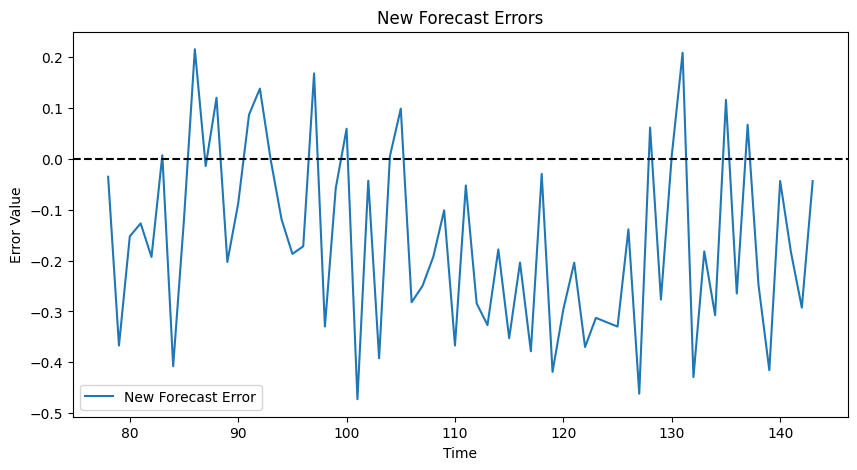

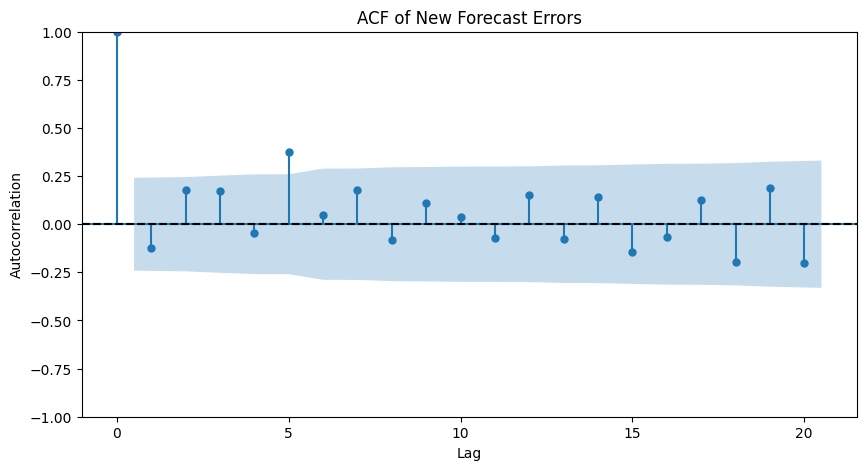

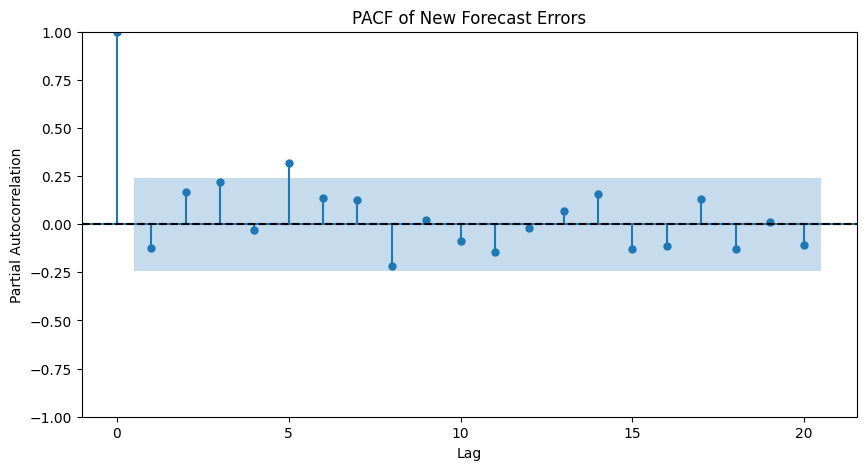

In [54]:
# Calculate new forecast errors and test for unbiasedness and autocorrelation.
test_df = fit_df.iloc[50:].copy()  # Use the fitted dataframe to get test data

test_df['new_diff'] = test_df['unemp_effect'] - test_df['predicted']
test_df['new_mse'] = test_df['new_diff'] ** 2
new_testdf = pd.DataFrame({
	'H0': [],
	'T-statistic': [],
	'P-value': []
})

# Run t-tests for unbiasedness and autocorrelation of new mse
t_stat_new_mse, p_value_new_mse = stats.ttest_1samp(test_df['new_mse'], 0)
new_testdf.loc[len(new_testdf)] = {
	'H0': 'E(new_mse) = 0',
	'T-statistic': t_stat_new_mse,
	'P-value': p_value_new_mse
}

for lag in [4, 6, 8]:
	autocorr_new_mse = test_df['new_mse'].autocorr(lag=lag)
	autocorr_se_new_mse = np.sqrt(1 / len(test_df))
	t_stat_autocorr_new_mse = autocorr_new_mse / autocorr_se_new_mse if autocorr_se_new_mse > 0 else 0
	p_value_autocorr_new_mse = 2 * (1 - stats.norm.cdf(abs(t_stat_autocorr_new_mse)))
	new_testdf.loc[len(new_testdf)] = {
		'H0': f'Autocorr(new_mse, lag={lag}) = 0',
		'T-statistic': t_stat_autocorr_new_mse,
		'P-value': p_value_autocorr_new_mse
	}

new_testdf['Outcome'] = np.where(new_testdf['P-value'] < 0.05, 'R (H1)', 'Fail (H0)')
print('\nNew Forecast Unbiasedness Test Results:')
print(np.round(new_testdf, 4).to_string(index=False))

print(f'New Forecast Unconditional Mean Error: {np.round(test_df["new_diff"].mean(), 3)}')
# Plot the difference and MSE of the new forecasts to visually inspect for any patterns or autocorrelation
plt.figure(figsize=(10, 5))
plt.plot(test_df['new_diff'], label='New Forecast Error')
plt.title('New Forecast Errors')
plt.xlabel('Time')
plt.ylabel('Error Value')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()

### Print ACF and PACF
plt.figure(figsize=(10, 5))
plot_acf(test_df['new_diff'], lags=20, ax=plt.gca(), alpha=0.05) 
plt.title('ACF of New Forecast Errors')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.axhline(0, color='black', linestyle='--')
plt.show()

plt.figure(figsize=(10, 5))
plot_pacf(test_df['new_diff'], lags=20, ax=plt.gca(), alpha=0.05)
plt.title('PACF of New Forecast Errors')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.axhline(0, color='black', linestyle='--')
plt.show()

**(f) Briefly comment on the results.**

- We still have a constant forecast error, likely due to finite sample error
- Otherwise, this new AR(2) model has removed autocorrelation in the forecast errors.